Objective: This experiment evaluates how modifying the distribution of a key behavioral feature affects classification performance. We dynamically upsample or downsample high-activity segments of selected features and re-train multiple models (Muller loop), observing changes in F1 score, confusion matrix, specificity, and sensitivity.

This notebook demonstrates ML assignment on data distribution effects:
- Dataset: CERT Insider Threat r4.2 (user behavior → insider detection)
- Feature importance via Gini + SHAP
- Muller loop: 5 classifiers (MLP, RF, SVM, LogReg, XGBoost)
- Interactive dashboard with sliders to upsample/downsample features
- SMOTE for oversampling minority class
- Baseline comparison showing F1 delta
- Dynamic confusion matrix + specificity vs sensitivity plots
- Goal: Show how changing data distribution affects model performance

In [16]:
# @title AI prompt cell

import ipywidgets as widgets
from IPython.display import display, HTML, Markdown,clear_output
from google.colab import ai

dropdown = widgets.Dropdown(
    options=[],
    layout={'width': 'auto'}
)

def update_model_list(new_options):
    dropdown.options = new_options
update_model_list(ai.list_models())

text_input = widgets.Textarea(
    placeholder='Ask me anything....',
    layout={'width': 'auto', 'height': '100px'},
)

button = widgets.Button(
    description='Submit Text',
    disabled=False,
    tooltip='Click to submit the text',
    icon='check'
)

output_area = widgets.Output(
     layout={'width': 'auto', 'max_height': '300px','overflow_y': 'scroll'}
)

def on_button_clicked(b):
    with output_area:
        output_area.clear_output(wait=False)
        accumulated_content = ""
        for new_chunk in ai.generate_text(prompt=text_input.value, model_name=dropdown.value, stream=True):
            if new_chunk is None:
                continue
            accumulated_content += new_chunk
            clear_output(wait=True)
            display(Markdown(accumulated_content))

button.on_click(on_button_clicked)
vbox = widgets.GridBox([dropdown, text_input, button, output_area])

display(HTML("""
<style>
.widget-dropdown select {
    font-size: 18px;
    font-family: "Arial", sans-serif;
}
.widget-textarea textarea {
    font-size: 18px;
    font-family: "Arial", sans-serif;
}
</style>
"""))
display(vbox)


GridBox(children=(Dropdown(layout=Layout(width='auto'), options=('google/gemini-2.5-flash', 'google/gemini-2.5…

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# === Rebuild DS3 from CERT r4.2 ===

import pandas as pd
import numpy as np

# Load your dataset (edit path if needed)
R42_PATH = "/content/drive/MyDrive/AegisAI/r4.2"
ANS_PATH = "/content/drive/MyDrive/AegisAI/answers"

logon = pd.read_csv(f"{R42_PATH}/logon.csv")
email = pd.read_csv(f"{R42_PATH}/email.csv")
device = pd.read_csv(f"{R42_PATH}/device.csv")
file_df = pd.read_csv(f"{R42_PATH}/file.csv")
labels = pd.read_csv(f"{ANS_PATH}/insiders.csv")

labels['user'] = labels['user'].astype(str)
insider_users = set(labels['user'])

# --- LOGON FEATURES ---
logon['date'] = pd.to_datetime(logon['date'], errors='coerce')
logon['hour'] = logon['date'].dt.hour
logon['after_hours'] = ((logon['hour'] < 8) | (logon['hour'] > 18)).astype(int)

ds1 = logon.groupby('user').agg(
    total_logons=('user','count'),
    after_hours_logons=('after_hours','sum'),
    distinct_pcs=('pc','nunique')
).reset_index()

# --- EMAIL FEATURES ---
email_features = email.groupby('user').agg(
    total_emails=('user','count'),
    distinct_recipients=('to','nunique')
).reset_index()

ds2 = ds1.merge(email_features, on='user', how='left').fillna(0)

# --- DEVICE FEATURES ---
device_features = device.groupby('user').agg(
    device_events=('user','count'),
    distinct_device_pcs=('pc','nunique')
).reset_index()

# --- FILE FEATURES ---
file_features = file_df.groupby('user').agg(
    file_events=('user','count'),
    distinct_file_pcs=('pc','nunique')
).reset_index()

# --- DS3 ---
ds3 = ds2.merge(device_features, on='user', how='left')
ds3 = ds3.merge(file_features, on='user', how='left')
ds3.fillna(0, inplace=True)

ds3['insider'] = ds3['user'].astype(str).isin(insider_users).astype(int)

print("DS3 built:", ds3.shape)
ds3.head()

DS3 built: (1000, 11)


,user,total_logons,after_hours_logons,distinct_pcs,total_emails,distinct_recipients,device_events,distinct_device_pcs,file_events,distinct_file_pcs,insider
0,AAE0190,692,0,1,4711,1529,0.0,0.0,0.0,0.0,0
1,AAF0535,328,0,1,480,299,688.0,1.0,357.0,1.0,1
2,AAF0791,692,0,1,3012,1251,0.0,0.0,0.0,0.0,0
3,AAL0706,692,346,1,336,216,0.0,0.0,0.0,0.0,0
4,AAM0658,458,234,1,659,365,13.0,1.0,31.0,1.0,1


In [3]:
!pip install xgboost imbalanced-learn shap -q

In [4]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, confusion_matrix, roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

import plotly.graph_objects as go
import ipywidgets as widgets
from IPython.display import display, clear_output

print("All imports successful!")

All imports successful!


In [5]:
FEATURE_COLS = [col for col in ds3.columns if col not in ['user', 'insider']]

X = ds3[FEATURE_COLS].copy()
y = ds3['insider'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (700, 9)
Test shape: (300, 9)


## Baseline Modeling

Before modifying data distribution, a baseline Muller loop was executed on the original training data.
F1 score was used as the primary goodness metric, alongside ROC-AUC, specificity, and sensitivity.
This establishes a reference performance level for comparison after distribution shifts.

FEATURE IMPORTANCE

In [6]:
rf_imp = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
rf_imp.fit(X_train, y_train)

importances = pd.Series(rf_imp.feature_importances_, index=X_train.columns).sort_values(ascending=False)

print("Feature Importance (Gini):")
display(importances)

KEY_FEATURE_DEFAULT = importances.index[0]
print(f"\nMost important feature: {KEY_FEATURE_DEFAULT}")


Feature Importance (Gini):


,0
total_logons,0.303252
device_events,0.156952
file_events,0.144473
distinct_device_pcs,0.115730
total_emails,0.082186
distinct_file_pcs,0.059474
distinct_pcs,0.054319
distinct_recipients,0.050070
after_hours_logons,0.033544



Most important feature: total_logons


SHAP FEATURE IMPORTANCE

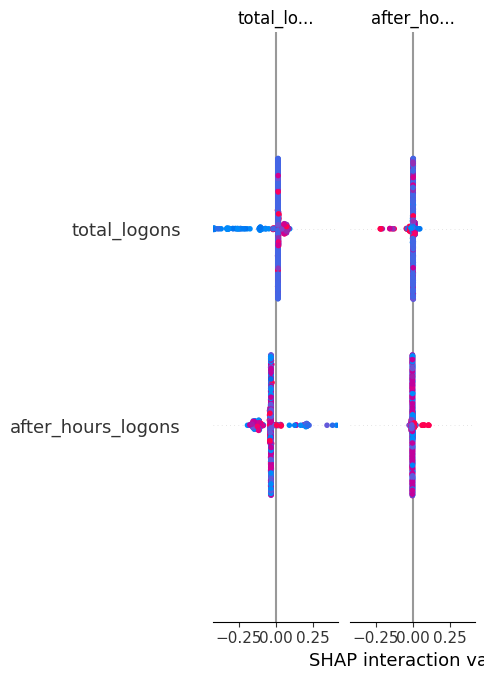

In [8]:
import shap

explainer = shap.TreeExplainer(rf_imp)
shap_values = explainer.shap_values(X_train)

# Fix for different SHAP versions
if isinstance(shap_values, list):
    # Old SHAP version - returns list [class_0, class_1]
    shap.summary_plot(shap_values[1], X_train, plot_type="bar")
else:
    # New SHAP version - returns single array
    shap.summary_plot(shap_values, X_train, plot_type="bar")

RESAMPLING FUNCTIONS

In [9]:
def resample_by_feature_quantile(X, y, feature, q=0.80, multiplier=1.0, random_state=42):
    rng = np.random.default_rng(random_state)
    X = X.copy()
    y = y.copy()

    thresh = X[feature].quantile(q)
    mask = X[feature] >= thresh

    X_hi, y_hi = X[mask], y[mask]
    X_lo, y_lo = X[~mask], y[~mask]

    n_hi = len(X_hi)
    if n_hi == 0:
        return X, y, thresh

    new_n_hi = int(np.round(n_hi * multiplier))

    if multiplier == 1.0:
        X_new = pd.concat([X_lo, X_hi], axis=0)
        y_new = pd.concat([y_lo, y_hi], axis=0)
        return X_new.sample(frac=1.0, random_state=random_state), y_new.loc[X_new.index], thresh

    if multiplier > 1.0:
        idx = rng.choice(X_hi.index.to_numpy(), size=new_n_hi, replace=True)
        X_hi_new = X_hi.loc[idx]
        y_hi_new = y_hi.loc[idx]
    else:
        new_n_hi = max(1, new_n_hi)
        idx = rng.choice(X_hi.index.to_numpy(), size=new_n_hi, replace=False)
        X_hi_new = X_hi.loc[idx]
        y_hi_new = y_hi.loc[idx]

    X_new = pd.concat([X_lo, X_hi_new], axis=0)
    y_new = pd.concat([y_lo, y_hi_new], axis=0)

    X_new = X_new.sample(frac=1.0, random_state=random_state)
    y_new = y_new.loc[X_new.index]
    return X_new, y_new, thresh


def resample_with_smote(X, y, random_state=42):
    smote = SMOTE(random_state=random_state)
    X_resampled, y_resampled = smote.fit_resample(X, y)
    return pd.DataFrame(X_resampled, columns=X.columns), pd.Series(y_resampled)

print("Resampling functions defined!")

Resampling functions defined!


## Distribution Modification Strategy

The selected key feature was divided into high-activity and low-activity segments using a quantile threshold.
The multiplier slider dynamically adjusts the frequency of the high-activity segment:

- Multiplier > 1 → Upsampling
- Multiplier < 1 → Downsampling

The test set remains fixed to ensure valid performance comparison.

In [10]:
def compute_spec_sens(cm):
    tn, fp, fn, tp = cm.ravel()
    sens = tp / (tp + fn + 1e-9)
    spec = tn / (tn + fp + 1e-9)
    return spec, sens


def muller_loop_classification(Xtr, ytr, Xte, yte):
    models = {
        "MLP": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", MLPClassifier(hidden_layer_sizes=(64,32), max_iter=300, random_state=42))
        ]),
        "RandomForest": RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1),
        "SVM": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", SVC(probability=True, kernel="rbf", random_state=42))
        ]),
        "LogReg": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42))
        ]),
        "XGBoost": XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss', verbosity=0),
    }

    rows = []
    artifacts = {}

    for name, model in models.items():
        model.fit(Xtr, ytr)
        pred = model.predict(Xte)

        proba = None
        if hasattr(model, "predict_proba"):
            proba = model.predict_proba(Xte)[:, 1]

        f1 = f1_score(yte, pred, zero_division=0)
        auc = roc_auc_score(yte, proba) if proba is not None else np.nan
        cm = confusion_matrix(yte, pred)
        spec, sens = compute_spec_sens(cm)

        rows.append({
            "Model": name,
            "F1": f1,
            "ROC_AUC": auc,
            "Specificity(TNR)": spec,
            "Sensitivity(TPR)": sens
        })
        artifacts[name] = {"cm": cm, "pred": pred, "proba": proba}

    results = pd.DataFrame(rows).sort_values("F1", ascending=False).reset_index(drop=True)
    return results, artifacts

print("Muller loop defined!")

Muller loop defined!


## Muller Loop Implementation

Five algorithms were evaluated during each distribution shift:
- MLP
- Random Forest
- SVM
- Logistic Regression
- XGBoost

For each resampling round, the models are retrained and evaluated using F1 score, ROC-AUC, confusion matrix, specificity, and sensitivity.

BASELINE

In [11]:
print("Computing BASELINE (no distribution change)...")

baseline_results, baseline_artifacts = muller_loop_classification(X_train, y_train, X_test, y_test)

print("\nBASELINE RESULTS:")
display(baseline_results)

BASELINE_F1 = dict(zip(baseline_results['Model'], baseline_results['F1']))
BASELINE_AUC = dict(zip(baseline_results['Model'], baseline_results['ROC_AUC']))

print("\nBaseline stored!")

Computing BASELINE (no distribution change)...

BASELINE RESULTS:


,Model,F1,ROC_AUC,Specificity(TNR),Sensitivity(TPR)
0,XGBoost,0.950000,0.997269,1.000000,0.904762
1,RandomForest,0.926829,0.997440,0.996416,0.904762
2,MLP,0.684211,0.922171,0.985663,0.619048
3,LogReg,0.551724,0.871992,0.924731,0.761905
4,SVM,0.173913,0.933265,1.000000,0.095238



Baseline stored!


PLOTTING FUNCTIONS

In [12]:
def plot_distribution(before, after, feature, thresh):
    fig = go.Figure()
    fig.add_trace(go.Histogram(x=before[feature], name="Before", opacity=0.6))
    fig.add_trace(go.Histogram(x=after[feature], name="After", opacity=0.6))
    fig.add_vline(x=float(thresh), line_dash="dash", annotation_text="Threshold")
    fig.update_layout(barmode="overlay", title=f"Distribution: {feature}")
    return fig


def plot_confusion(cm, title="Confusion Matrix"):
    fig = go.Figure(data=go.Heatmap(
        z=cm,
        x=["Pred 0", "Pred 1"],
        y=["True 0", "True 1"],
        text=cm,
        texttemplate="%{text}",
        colorscale="Blues"
    ))
    fig.update_layout(title=title)
    return fig


def plot_spec_sens(results_df):
    fig = go.Figure()
    fig.add_trace(go.Scatter(
        x=results_df["Specificity(TNR)"],
        y=results_df["Sensitivity(TPR)"],
        mode="markers+text",
        text=results_df["Model"],
        textposition="top center",
        marker=dict(size=12)
    ))
    fig.update_layout(title="Specificity vs Sensitivity", xaxis_title="Specificity", yaxis_title="Sensitivity")
    return fig

print("Plotting functions defined!")

Plotting functions defined!


DASHBOARD

In [13]:
results_history = []

feature_dropdown = widgets.Dropdown(
    options=list(X_train.columns),
    value=KEY_FEATURE_DEFAULT,
    description="Feature:"
)

quantile_slider = widgets.FloatSlider(
    value=0.80, min=0.50, max=0.95, step=0.05,
    description="Quantile:"
)

mult_slider = widgets.FloatSlider(
    value=1.0, min=0.2, max=3.0, step=0.1,
    description="Multiplier:"
)

model_dropdown = widgets.Dropdown(
    options=["MLP", "RandomForest", "SVM", "LogReg", "XGBoost"],
    value="RandomForest",
    description="CM Model:"
)

use_smote = widgets.Checkbox(value=False, description="Use SMOTE")

out = widgets.Output()


def run_dashboard(feature, quantile, multiplier, cm_model, smote):
    with out:
        clear_output(wait=True)

        X_before = X_train.copy()

        if smote:
            X_after, y_after = resample_with_smote(X_train, y_train)
            thresh = X_train[feature].quantile(quantile)
        else:
            X_after, y_after, thresh = resample_by_feature_quantile(
                X_train, y_train, feature=feature, q=quantile, multiplier=multiplier
            )

        results, artifacts = muller_loop_classification(X_after, y_after, X_test, y_test)

        results['F1_Delta'] = results.apply(lambda r: r['F1'] - BASELINE_F1[r['Model']], axis=1)

        print(f"Feature: {feature} | Multiplier: {multiplier} | SMOTE: {smote}")
        print(f"Samples: {len(X_train)} -> {len(X_after)}\n")
        display(results.style.format({"F1":"{:.4f}", "ROC_AUC":"{:.4f}", "F1_Delta":"{:+.4f}"}))

        results_history.append({'multiplier': multiplier, 'results': results.copy()})

        plot_distribution(X_before, X_after, feature, thresh).show()
        plot_confusion(artifacts[cm_model]["cm"], f"Confusion Matrix: {cm_model}").show()
        plot_spec_sens(results).show()


ui = widgets.VBox([
    widgets.HBox([feature_dropdown, model_dropdown]),
    widgets.HBox([quantile_slider, mult_slider]),
    use_smote
])

display(ui, out)


def on_change(change=None):
    run_dashboard(feature_dropdown.value, quantile_slider.value, mult_slider.value, model_dropdown.value, use_smote.value)

feature_dropdown.observe(on_change, names="value")
quantile_slider.observe(on_change, names="value")
mult_slider.observe(on_change, names="value")
model_dropdown.observe(on_change, names="value")
use_smote.observe(on_change, names="value")

on_change()

Output()

## Interactive Dashboard

The dashboard enables dynamic modification of feature distribution using a slider.
Each adjustment triggers:
- Resampling of the training data
- Re-training of the Muller loop
- Recalculation of performance metrics
- Dynamic update of the confusion matrix
- Updated specificity vs sensitivity visualization

CONCLUSION

In [14]:
print("""
ASSIGNMENT CHECKLIST:
✅ Feature importance (Gini + SHAP)
✅ Muller loop (5 algorithms: MLP, RF, SVM, LogReg, XGBoost)
✅ Upsampling / Downsampling with slider
✅ SMOTE option
✅ Baseline comparison with F1 delta
✅ Dynamic confusion matrix
✅ Specificity vs Sensitivity plot
✅ Distribution visualization
""")


ASSIGNMENT CHECKLIST:
✅ Feature importance (Gini + SHAP)
✅ Muller loop (5 algorithms: MLP, RF, SVM, LogReg, XGBoost)
✅ Upsampling / Downsampling with slider
✅ SMOTE option
✅ Baseline comparison with F1 delta
✅ Dynamic confusion matrix
✅ Specificity vs Sensitivity plot
✅ Distribution visualization

